# ChipWhisperer 입문 강의자료
## 부채널 분석(Side-Channel Analysis) 플랫폼 실습

---

### 🎯 강의 목표

이 노트북은 ChipWhisperer 플랫폼을 처음 접하는 입문자를 위한 자료입니다.  
다음 세 가지를 단계적으로 학습합니다:

| 단계 | 내용 |
|:---:|:---|
| **1단계** | ChipWhisperer와 데이터 송수신 — 명령어 구조 이해 및 입출력 검증 |
| **2단계** | 파형(Power Trace) 수집 파라미터 설정 — 샘플 수, 샘플레이트, 프리샘플 |
| **3단계** | 다량의 파형 수집 및 HDF5 데이터베이스 저장 |

---

### 🔧 실험 환경

```
호스트 PC (Python / Jupyter)
    │
    │  USB
    ▼
ChipWhisperer-Husky (scope + 제어보드)
    │
    │  20-pin 커넥터
    ▼
CW308 타겟보드 - STM32F303 마이크로컨트롤러
```

- **scope** : 전력 파형을 측정하는 오실로스코프 역할  
- **target** : 암호 연산을 수행하는 타겟 마이크로컨트롤러와의 통신 인터페이스  
- 타겟 펌웨어는 `simpleserial` 프로토콜을 사용해 호스트와 통신합니다

---

## 📦 사전 준비: 플랫폼 설정 및 초기화

### PLATFORM 변수 설정

사용하는 ChipWhisperer 하드웨어 종류를 지정합니다.  
여기서는 **HUSKY + CW308_STM32F3**를 사용합니다.

In [1]:
# 사용 중인 ChipWhisperer 플랫폼을 지정합니다
# CW308_STM32F3: CW308 UFO 보드 + 본 예제에서는 STM32F303 타겟 사용
# CWHUSKY      : ChipWhisperer-Husky with CW313 + SAM4S 사용 시

PLATFORM = 'CW308_STM32F3'  
# PLATFORM = 'CWHUSKY'    # CW313 + SAM4S 플랫폼 사용 시 


### 공통 설정 파일 실행

`My_Setup.ipynb`를 실행하면 아래 작업이 자동으로 진행됩니다:
- ChipWhisperer 라이브러리 임포트 (`chipwhisperer`, `numpy`, `h5py` 등)
- `scope` / `target` 객체 생성 및 USB 연결
- 타겟 펌웨어 컴파일 및 업로드
- 보조 함수 정의 (`my_fsr_cmd`, `my_get_trace`, `my_setting_num_samples` 등)

In [2]:
# 공통 설정 노트북 실행 (scope, target 객체 초기화)
%run '../base/My_Setup.ipynb'

SS_VER set to SS_VER_2_1
SS_VER set to SS_VER_2_1
.
Welcome to another exciting ChipWhisperer target build!!
.
Cleaning project:
rm -f -- simpleserial-base-CW308_CC2538.hex simpleserial-base-CW301_AVR.hex simpleserial-base-CW303.hex simpleserial-base-CW304.hex simpleserial-base-CW308_MEGARF.hex simpleserial-base-CW308_SAM4L.hex simpleserial-base-CW308_STM32F0.hex simpleserial-base-CW308_STM32F1.hex simpleserial-base-CW308_STM32F2.hex simpleserial-base-CW308_STM32F3.hex simpleserial-base-CW308_STM32F4.hex simpleserial-base-CW308_K24F.hex simpleserial-base-CW308_NRF52.hex simpleserial-base-CW308_AURIX.hex simpleserial-base-CW308_SAML11.hex simpleserial-base-CW308_EFM32TG11B.hex simpleserial-base-CWLITEARM.hex simpleserial-base-CWLITEXMEGA.hex simpleserial-base-CWNANO.hex simpleserial-base-CWHUSKY.hex simpleserial-base-CW308_K82F.hex simpleserial-base-CW308_PSOC62.hex simpleserial-base-CW308_IMXRT1062.hex simpleserial-base-CW308_FE310.hex simpleserial-base-CW308_EFR32MG21A.hex simpleseria

---

## 📡 1단계: 타겟 보드와 데이터 송수신

### 1.1 SimpleSerial 프로토콜 개요

ChipWhisperer는 **SimpleSerial 프로토콜**로 타겟과 통신합니다.  
각 명령 패킷의 구조는 다음과 같습니다:

```
┌──────┬──────┬─────────┬──────────┬─────┐
│ cmd  │ scmd │  len    │  data[]  │ crc │
│(1B)  │(1B)  │  (1B)   │(최대245B)│(1B) │
└──────┴──────┴─────────┴──────────┴─────┘
```

| 필드 | 의미 |
|:----:|:----|
| `cmd`  | 명령 종류 (0x81=초기화/쓰기, 0x82=연산실행, 0x83=결과읽기) |
| `scmd` | 하위 명령 문자 ('k'=키, 'p'=평문, 'l'=길이, 'c'=연산, 'r'=결과) |
| `len`  | 데이터 바이트 수 |
| `data` | 실제 전송 데이터 |
| `crc`  | 오류 검출용 체크섬 |

### 1.2 보조 함수 `my_fsr_cmd()` 소개

```python
my_fsr_cmd(target, cmd, scmd_char, data, payload_only=False)
```

- 위의 패킷 송수신 + CRC 검증을 한 번에 처리하는 래퍼 함수입니다
- `payload_only=True`이면 수신 데이터 부분만 `bytearray`로 반환합니다
- `payload_only=False`(기본)이면 전체 패킷 바이트를 반환합니다

### 1.3 테스트 데이터 준비

오늘 실험에서는 타겟 보드가 `data_k XOR data_p` 연산을 수행합니다.  
임의의 245바이트 데이터를 생성하여 통신을 테스트합니다.

> 💡 **왜 245바이트?**  
> SimpleSerial v2 패킷에서 데이터 필드 최대 크기가 245바이트입니다.  
> (cmd 1B + scmd 1B + len 1B + data 245B + crc 1B = 249B, UART 버퍼 고려)

In [3]:
MAX_DATA_LEN = 245  # 한 번에 전송 가능한 최대 데이터 크기 (바이트)

# 재현성을 위해 시드 고정
random.seed(1)

# 무작위 키(key) 및 평문(plaintext) 데이터 생성
data_k = bytearray(random.randint(0, 255) for _ in range(MAX_DATA_LEN))
data_p = bytearray(random.randint(0, 255) for _ in range(MAX_DATA_LEN))

print('=== 생성된 테스트 데이터 ===')
print(f'data_k (앞 16바이트): {data_k[:16].hex(" ")} ...')
print(f'data_p (앞 16바이트): {data_p[:16].hex(" ")} ...')
print(f'데이터 길이: {len(data_k)} 바이트')

=== 생성된 테스트 데이터 ===
data_k (앞 16바이트): 44 20 82 3c fd e6 f1 c2 6b 30 f9 0e c7 dd 01 e4 ...
data_p (앞 16바이트): 17 97 06 07 2e d3 3a 14 60 7a d7 52 3b e6 55 7b ...
데이터 길이: 245 바이트


### 1.4 데이터 전송: 키(k) 및 평문(p) 쓰기

타겟 보드의 메모리에 `data_k`와 `data_p`를 씁니다.  
전송 후 타겟이 에코(echo) 응답을 보내오면 전송 성공을 확인할 수 있습니다.

In [4]:
# ── 키 데이터(data_k) 전송 ──────────────────────────────
# cmd=0x81(초기화/쓰기), scmd='k'(키), data=data_k

print('[ 키(k) 전송 ]')
target.flush()  # 수신 버퍼 초기화 (이전 잔여 데이터 제거)

target.send_cmd(cmd=0x81, scmd=ord('k'), data=data_k)
ret_k = target.read_cmd(timeout=2000)  # 최대 2초 대기

# 응답 패킷 파싱
# ret_k[0]       : cmd (0x81)
# ret_k[1]       : scmd (문자 'k'의 ASCII 값)
# ret_k[2]       : 데이터 길이
# ret_k[3:3+len] : 에코된 데이터
# ret_k[-2]      : CRC
print(f'  scmd 문자  : {chr(ret_k[1])}')
print(f'  데이터 길이 : {ret_k[2]} 바이트')
print(f'  에코 데이터 : {ret_k[3:3+ret_k[2]].hex(" ")} ...')
print(f'  CRC       : {hex(ret_k[-2])}')

[ 키(k) 전송 ]
  scmd 문자  : k
  데이터 길이 : 245 바이트
  에코 데이터 : 44 20 82 3c fd e6 f1 c2 6b 30 f9 0e c7 dd 01 e4 88 75 34 a2 0f 0b 0d 04 c3 6e d8 0e 71 e0 fd 77 b0 76 70 eb 94 0b d5 33 5f 97 3d aa d8 61 9b 91 ff c9 11 f5 7c ce d4 58 bb bf 2c e0 37 53 c9 bd fa 0f f0 16 9d c9 57 56 74 06 66 76 cf b0 b4 eb 89 02 c4 42 69 da 1c f6 ba 66 d3 f8 b6 d4 b1 00 a9 ea 0e 75 5a 5c 2e 82 10 24 2a 08 e7 07 8f 7f 89 38 5e b0 94 23 55 51 82 56 8b 96 e8 a4 fe f2 3a 0c 9f c5 af d7 60 84 37 81 6b dd 0a 73 09 cb 4a 12 52 e4 da 70 e6 72 0f ca a4 da 1e 98 40 6c 18 9c 24 27 9e 98 51 d5 81 42 04 13 6f eb 57 13 c1 66 b1 32 69 dd 63 fc 35 c7 97 ff 08 a6 cd 90 09 50 66 a7 45 ad db 6d 88 31 c2 b0 f8 78 21 14 2b 44 56 55 6d 89 aa 82 bc ad ae 3a 95 78 fa 45 35 a4 14 d0 25 c2 4b 40 ae 3a c1 27 72 29 88 ba 97 3a ea 8d 37 ...
  CRC       : 0x8f


In [5]:
# ── 평문 데이터(data_p) 전송 ─────────────────────────────
# cmd=0x81(초기화/쓰기), scmd='p'(평문), data=data_p

print('[ 평문(p) 전송 ]')
target.flush()

target.send_cmd(cmd=0x81, scmd=ord('p'), data=data_p)
ret_p = target.read_cmd(timeout=2000)

print(f'  scmd 문자  : {chr(ret_p[1])}')
print(f'  데이터 길이 : {ret_p[2]} 바이트')
print(f'  에코 데이터 : {ret_p[3:3+ret_p[2]].hex(" ")} ...')
print(f'  CRC       : {hex(ret_p[-2])}')

[ 평문(p) 전송 ]
  scmd 문자  : p
  데이터 길이 : 245 바이트
  에코 데이터 : 17 97 06 07 2e d3 3a 14 60 7a d7 52 3b e6 55 7b 51 34 de c1 96 81 f4 a1 33 6a a2 14 0d 05 97 a3 e6 c8 a0 cc 20 20 a2 e9 39 80 6e f0 b6 84 5d 6a 9d 65 7e b8 29 8f 2d e5 2e ad 74 c7 9d 15 a7 5f a2 9b 7d ab 33 2f 7d 70 0a 7c cd 25 89 24 26 0b 05 94 b7 fc f0 4e 33 a7 27 58 5b 4c 48 a3 9c 36 96 40 69 48 10 a1 69 5b 99 dd 50 18 7e 81 20 e4 dc 80 e0 e8 05 ca ad 57 84 f8 0c d5 09 1f b5 46 40 46 84 8d cb cd 58 2d 77 f8 03 5a a2 e0 73 7a a0 fd f5 73 d3 ac 8c 70 18 24 bc 51 68 9f 98 99 be 54 ed 2b 3f c1 5a 4f 80 da 6f 1a fd c9 b2 c4 54 14 2e 82 33 88 2a 47 29 e3 7b c3 dd cb 54 a6 e0 40 f9 6c 3d dc d1 3c 97 8e 7f c1 02 61 e0 0a 0f 7c 85 69 58 91 4b 66 8b 9f 80 e4 56 b6 fb d7 3e 6a c4 68 91 37 0c 3c 06 97 45 26 bf 9f df b6 a5 00 3f e2 e6 ...
  CRC       : 0xb2


### 1.5 출력 길이(l) 설정

타겟에게 "결과를 몇 바이트 돌려줄 것인지"를 알려줍니다.
출력 길이 이외에도 몇 바이트를 연산 할지도 결정합니다.  
- simpleserial_main/simpleserial-base.c -> 변수 global_len 참조 

In [6]:
# ── 출력 길이 설정 ──────────────────────────────────────
# cmd=0x81, scmd='l', data=[MAX_DATA_LEN]  (1바이트 길이값)

print('[ 출력 길이(l) 설정 ]')
target.flush()

target.send_cmd(cmd=0x81, scmd=ord('l'), data=bytearray([MAX_DATA_LEN]))
ret_len = target.read_cmd(timeout=2000)

print(f'  scmd 문자            : {chr(ret_len[1])}')
print(f'  데이터 길이(항상 1)    : {ret_len[2]} 바이트')
print(f'  에코 데이터(설정된 길이) : {ret_len[3:3+ret_len[2]][0]} 바이트')
print(f'  CRC                 : {hex(ret_len[-2])}')

[ 출력 길이(l) 설정 ]
  scmd 문자            : l
  데이터 길이(항상 1)    : 1 바이트
  에코 데이터(설정된 길이) : 245 바이트
  CRC                 : 0x1d


### 1.6 연산 실행 및 결과 수신

`cmd=0x82` 명령으로 타겟 연산을 트리거한 뒤,  
`cmd=0x83`으로 결과를 읽어옵니다.

In [7]:
# ── 연산 실행 ───────────────────────────────────────────
# cmd=0x82('실행'), scmd='c'(compute), data=[] (없음)

print('[ 연산 실행 (k XOR p) ]')
target.flush()
target.send_cmd(cmd=0x82, scmd=ord('c'), data=[])
# 이 시점에 타겟 MCU가 연산을 수행합니다 (트리거 신호 발생)
print('  → 타겟 연산 완료')

[ 연산 실행 (k XOR p) ]
  → 타겟 연산 완료


In [8]:
# ── 결과 읽기 ───────────────────────────────────────────
# cmd=0x83('결과읽기'), scmd='r'(result), data=[] (없음)

print('[ 결과 수신 ]')
target.flush()
target.send_cmd(cmd=0x83, scmd=ord('r'), data=[])
ret_k_XOR_p = target.read_cmd(timeout=2000)

print(f'  scmd 문자   : {chr(ret_k_XOR_p[1])}')
print(f'  데이터 길이 : {ret_k_XOR_p[2]} 바이트')
print(f'  결과 데이터 : {ret_k_XOR_p[3:3+ret_k_XOR_p[2]].hex(" ")} ...')
print(f'  CRC         : {hex(ret_k_XOR_p[-2])}')

[ 결과 수신 ]
  scmd 문자   : r
  데이터 길이 : 245 바이트
  결과 데이터 : 53 b7 84 3b d3 35 cb d6 0b 4a 2e 5c fc 3b 54 9f d9 41 ea 63 99 8a f9 a5 f0 04 7a 1a 7c e5 6a d4 56 be d0 27 b4 2b 77 da 66 17 53 5a 6e e5 c6 fb 62 ac 6f 4d 55 41 f9 bd 95 12 58 27 aa 46 6e e2 58 94 8d bd ae e6 2a 26 7e 7a ab 53 46 94 92 e0 8c 96 73 be 99 94 2f 51 9d 3e 88 b4 fe 77 2d 36 3f aa 67 3d 4a fd 47 d9 89 f9 7a 10 99 86 af 9b 55 b8 be 58 91 e9 f8 06 06 ae 87 43 e1 bb 4b b4 7a 4a 1b 48 64 1a 38 a9 40 79 68 87 a8 93 7a b1 ea ef a7 97 09 dc 6a 02 17 ee 18 8b 76 07 d8 f5 a6 c8 c9 0c a1 59 0b 9a 01 98 6b 09 92 22 e5 d7 95 72 9f b0 5a 55 49 bb 1c 24 ec 3c d5 6d 99 36 e9 10 9f cb 78 71 0a 51 1f bf bd 71 fa 19 c1 1e 24 38 d3 3c 35 18 e1 e4 37 32 2e de c3 ce 01 92 0b ce d0 b8 b4 f5 47 7c a8 ad 84 01 cd b6 57 0c 32 3a d5 6f d1 ...
  CRC         : 0xac


### 1.7 골든 모델(Golden Model)과 결과 비교

Python에서 직접 계산한 `k XOR p` 결과와 타겟의 결과를 비교해  
통신 및 연산이 정확한지 검증합니다.

> 💡 **골든 모델(Golden Model)**  
> 타겟 하드웨어 없이 호스트 PC에서 동일한 연산을 수행한 기준 출력값입니다.  
> 하드웨어 출력과 일치하면 펌웨어와 통신 모두 정상임을 의미합니다.

In [9]:
# 타겟 보드에서 받은 결과
Return_k_XOR_p = ret_k_XOR_p[3 : 3 + ret_k_XOR_p[2]]

# 호스트(Python)에서 직접 계산한 골든 모델
Golden_k_XOR_p = bytes(x ^ y for x, y in zip(data_k, data_p))

print('=== 결과 비교 ===')
print(f'타겟 결과  : {Return_k_XOR_p.hex(" ")} ...')
print(f'골든 모델  : {Golden_k_XOR_p.hex(" ")} ...')
print()

if Golden_k_XOR_p == Return_k_XOR_p:
    print('✅ 통신 및 연산 검증 성공! (타겟 출력 == 골든 모델)')
else:
    print('❌ 불일치! 통신 오류 또는 펌웨어 오류를 확인하세요.')

=== 결과 비교 ===
타겟 결과  : 53 b7 84 3b d3 35 cb d6 0b 4a 2e 5c fc 3b 54 9f d9 41 ea 63 99 8a f9 a5 f0 04 7a 1a 7c e5 6a d4 56 be d0 27 b4 2b 77 da 66 17 53 5a 6e e5 c6 fb 62 ac 6f 4d 55 41 f9 bd 95 12 58 27 aa 46 6e e2 58 94 8d bd ae e6 2a 26 7e 7a ab 53 46 94 92 e0 8c 96 73 be 99 94 2f 51 9d 3e 88 b4 fe 77 2d 36 3f aa 67 3d 4a fd 47 d9 89 f9 7a 10 99 86 af 9b 55 b8 be 58 91 e9 f8 06 06 ae 87 43 e1 bb 4b b4 7a 4a 1b 48 64 1a 38 a9 40 79 68 87 a8 93 7a b1 ea ef a7 97 09 dc 6a 02 17 ee 18 8b 76 07 d8 f5 a6 c8 c9 0c a1 59 0b 9a 01 98 6b 09 92 22 e5 d7 95 72 9f b0 5a 55 49 bb 1c 24 ec 3c d5 6d 99 36 e9 10 9f cb 78 71 0a 51 1f bf bd 71 fa 19 c1 1e 24 38 d3 3c 35 18 e1 e4 37 32 2e de c3 ce 01 92 0b ce d0 b8 b4 f5 47 7c a8 ad 84 01 cd b6 57 0c 32 3a d5 6f d1 ...
골든 모델  : 53 b7 84 3b d3 35 cb d6 0b 4a 2e 5c fc 3b 54 9f d9 41 ea 63 99 8a f9 a5 f0 04 7a 1a 7c e5 6a d4 56 be d0 27 b4 2b 77 da 66 17 53 5a 6e e5 c6 fb 62 ac 6f 4d 55 41 f9 bd 95 12 58 27 aa 46 6e e2 58 94 8d bd ae e6 2a 26 7e 7a ab 53 4

---

## 📊 2단계: 파형 수집 파라미터 설정

### 2.1 개념 정리

부채널 분석의 핵심은 **전력 파형(Power Trace)**을 정밀하게 수집하는 것입니다.  
올바른 파라미터 설정이 분석 품질을 결정합니다.

```
          트리거 신호
              │
    ◄─────────┼────────────────────►  시간 축
              │
    │◄─pre──► │◄────── 연산 구간 ───────►│
    │samples  │                        │
    │         │                        │
              
    전체 samples = adc_mul * clocks + presamples    or    adc_mul * clocks // decimate
        (clocks : 타겟 연산 클럭 수)
```

| 파라미터 | 설명 |
|:--------:|:----|
| `samples` | 실제로 저장할 전체 샘플 수 |
| `adc_src & adc_mul` | ADC 클럭 소스 (샘플링 배수 설정) |
| `presamples` | 트리거 이전에 추가로 수집할 샘플 수 (트리거 앞 신호 수집 범위) |
| `decimate` | 다운샘플링 비율 (1=전체, 2=절반, ...) |
| `trig_count` | 트리거 ON → OFF 사이의 ADC 샘플 수 (읽기전용) |

최대 샘플 수는 하드웨어에 따라 다릅니다. - cwlite: 24400 - cw1200: 96000 - cwhusky: 131070

### 2.2 ADC 클럭 설정

ChipWhisperer-Husky는 타겟 MCU 클럭에 동기화된 ADC를 사용합니다.

```
scope.clock.adc_src  = 'clkgen_x4'   → MCU 클럭의 4배 속도로 샘플링
scope.clock.adc_mul = 4


scope.adc.presamples = 0             → 프리샘플링 없음 (트리거 후 신호만 수집)
scope.adc.decimate   = 1             → 다운샘플링 없음 (전체 유지)

presamples와 decimate는 동시 사용 불가
```

MCU가 7.37 MHz로 동작한다면 ADC는 **29.5 MHz**로 샘플링합니다.  
클럭 1주기당 4개 샘플을 얻으므로 파형이 더 정밀합니다.

In [10]:
# ── 스코프 기본 설정 및 타겟보드 리셋 ────────────────────

scope.default_setup()  # 스코프 초기화 (트리거, 게인, 샘플 수 등 기본값 로드)

scope.clock.adc_src = 'clkgen_x1'   # clkgen_x4 clkgen_x1
scope.clock.adc_mul = 1

RATIO_DECIMATE = 1    # 다운샘플링
NUM_PRESAMPLES = 0    # 트리거 이전 프리샘플 수 (다운샘플링이 1일때 사용 가능)


# reset_target(scope): 타겟 MCU를 하드 리셋하는 함수
# →  ../base/Setup_Generic.ipynb 에 정의
reset_target(scope)
time.sleep(1)  # 리셋 후 부팅 대기
reset_target(scope)
time.sleep(1)

print('스코프 및 타겟 초기화 완료')

(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:1628) scope.clock.adc_src is provided for backwards compability, but scope.clock.clkgen_src and scope.clock.adc_mul should be used for Husky.
(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:703) Target clock may drop; you may need to reset your target.


스코프 및 타겟 초기화 완료


### 2.3 파라미터 설정: 테스트용 데이터 준비

In [11]:
MAX_DATA_LEN   = 245  # 전송 데이터 크기

random.seed(1)
data_k = bytearray(random.randint(0, 255) for _ in range(MAX_DATA_LEN))
data_p = bytearray(random.randint(0, 255) for _ in range(MAX_DATA_LEN))

print(f'MAX_DATA_LEN   : {MAX_DATA_LEN}')
print(f'RATIO_DECIMATE : {RATIO_DECIMATE}')
print(f'NUM_PRESAMPLES : {NUM_PRESAMPLES}')

MAX_DATA_LEN   : 245
RATIO_DECIMATE : 1
NUM_PRESAMPLES : 0


### 2.4 `trig_count` 측정: 연산이 몇 클럭인가?

스코프를 `arm()` 한 상태에서 연산을 실행하면  
ChipWhisperer가 자동으로 트리거 구간의 클럭 수를 셉니다.

In [12]:
# ── 타겟에 데이터 주입 ──────────────────────────────────
my_fsr_cmd(target, 0x81, 'k', data_k)
my_fsr_cmd(target, 0x81, 'p', data_p)
my_fsr_cmd(target, 0x81, 'l', bytearray([MAX_DATA_LEN]))

# ── 스코프 무장(arm) → 연산 실행 → 캡처 대기 ────────────
scope.arm()                          # 트리거 대기 상태로 진입
my_fsr_cmd(target, 0x82, 'c', [])   # 연산 실행 (트리거 발생)

if scope.capture():                  # 파형 캡처 (타임아웃 시 True 반환)
    print('❌ 타겟 타임아웃!')
    sys.exit('Target timed out!')

# trig_count: 트리거 ON → OFF 동안의 ADC 샘플 수
print(f'\n⏱ 연산 구간 클럭 수  (trig_count) : {scope.adc.trig_count} samples')

# ── 샘플 수 계산 ────────────────────────────────────────
scope.adc.decimate = RATIO_DECIMATE
if RATIO_DECIMATE == 1:
    scope.adc.presamples = NUM_PRESAMPLES

# samples = (trig_count + presamples) ÷ decimate
scope.adc.samples = (scope.adc.trig_count // scope.adc.decimate) + scope.adc.presamples

print(f'   presamples   : {scope.adc.presamples}')
print(f'   decimate     : {scope.adc.decimate}')
print(f'✅ 최종 수집 샘플 수 (samples)     : {scope.adc.samples}')


⏱ 연산 구간 클럭 수  (trig_count) : 2980 samples
   presamples   : 0
   decimate     : 1
✅ 최종 수집 샘플 수 (samples)     : 2980


> 💡 **samples 설정 공식 해설**
> 
> - `trig_count`: 실제 연산에 걸리는 ADC 샘플 수  
> - `presamples`: 트리거 전에 추가할 여유 샘플 수  
> - `decimate`: 다운샘플링 비율 (1이면 전체, 2이면 절반)  
> 
> 이 값보다 짧게 설정하면 파형 끝이 잘리고,  
> 너무 길면 메모리 낭비 및 분석 속도 저하가 발생합니다.

---

## 🌊 3단계 (전): 파형 1개 수집 및 시각화

### 3.1 `my_setting_num_samples()` 함수 소개

위 2.4의 `trig_count` 측정 + `samples` 설정을 하나로 묶은 함수입니다.

```python
MAX_TR_LEN = my_setting_num_samples(target, scope, NUM_PRESAMPLES=NUM_PRESAMPLES, RATIO_DECIMATE=RATIO_DECIMATE)
# → 내부적으로 더미 연산 실행 → trig_count 측정 → scope.adc.samples 설정
# → 설정된 samples 값을 반환 (DB 배열 크기 사전 결정에 사용)
# → 파라미터 NUM_PRESAMPLES 또는 RATIO_DECIMATE 하나만 설정 가능
```

In [13]:
# 스코프 수집 파라미터 설정
scope.default_setup()  # 스코프 초기화 (트리거, 게인, 샘플 수 등 기본값 로드)

RATIO_DECIMATE = 1
NUM_PRESAMPLES = 0
scope.clock.adc_src = 'clkgen_x4'   # clkgen_x4 clkgen_x1
scope.clock.adc_mul = 4
reset_target(scope)
reset_target(scope)


MAX_DATA_LEN   = 245
random.seed(1)
data_k = bytearray(random.randint(0, 255) for _ in range(MAX_DATA_LEN))
data_p = bytearray(random.randint(0, 255) for _ in range(MAX_DATA_LEN))

# 타겟에 데이터 주입
my_fsr_cmd(target, 0x81, 'k', data_k)
my_fsr_cmd(target, 0x81, 'p', data_p)
my_fsr_cmd(target, 0x81, 'l', bytearray([MAX_DATA_LEN]))

# samples 자동 설정 및 반환
MAX_TR_LEN = my_setting_num_samples(target, scope, NUM_PRESAMPLES=NUM_PRESAMPLES, RATIO_DECIMATE=RATIO_DECIMATE)
print(f'\n파형 1개당 샘플 수(MAX_TR_LEN): {MAX_TR_LEN}')

(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:703) Target clock may drop; you may need to reset your target.
(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:1628) scope.clock.adc_src is provided for backwards compability, but scope.clock.clkgen_src and scope.clock.adc_mul should be used for Husky.


scope.adc.samples                        changed from 2980                      to 5000                     
scope.clock.clkgen_freq                  changed from 7371428.571428572         to 7363636.363636363        
scope.clock.adc_mul                      changed from 1                         to 4                        
scope.clock.adc_freq                     changed from 7371428.571428572         to 29454545.454545453       

파형 1개당 샘플 수(MAX_TR_LEN): 11920


### 3.2 파형 1개 수집 및 플롯

`my_get_trace(target, scope)` 함수는 내부적으로:
1. `scope.arm()` → 트리거 대기
2. `my_fsr_cmd(... 0x82 ...)` → 연산 실행
3. `scope.capture()` → 파형 수신
4. `my_fsr_cmd(... 0x83 ...)` → 결과 읽기

를 순서대로 실행하고 `(출력값, 파형 배열)`을 반환합니다.

출력값  : 53 b7 84 3b d3 35 cb d6 0b 4a 2e 5c fc 3b 54 9f d9 41 ea 63 99 8a f9 a5 f0 04 7a 1a 7c e5 6a d4 56 be d0 27 b4 2b 77 da 66 17 53 5a 6e e5 c6 fb 62 ac 6f 4d 55 41 f9 bd 95 12 58 27 aa 46 6e e2 58 94 8d bd ae e6 2a 26 7e 7a ab 53 46 94 92 e0 8c 96 73 be 99 94 2f 51 9d 3e 88 b4 fe 77 2d 36 3f aa 67 3d 4a fd 47 d9 89 f9 7a 10 99 86 af 9b 55 b8 be 58 91 e9 f8 06 06 ae 87 43 e1 bb 4b b4 7a 4a 1b 48 64 1a 38 a9 40 79 68 87 a8 93 7a b1 ea ef a7 97 09 dc 6a 02 17 ee 18 8b 76 07 d8 f5 a6 c8 c9 0c a1 59 0b 9a 01 98 6b 09 92 22 e5 d7 95 72 9f b0 5a 55 49 bb 1c 24 ec 3c d5 6d 99 36 e9 10 9f cb 78 71 0a 51 1f bf bd 71 fa 19 c1 1e 24 38 d3 3c 35 18 e1 e4 37 32 2e de c3 ce 01 92 0b ce d0 b8 b4 f5 47 7c a8 ad 84 01 cd b6 57 0c 32 3a d5 6f d1 ...
파형 길이: 11920 샘플
파형 최솟값: -0.5000,  최댓값: 0.2295


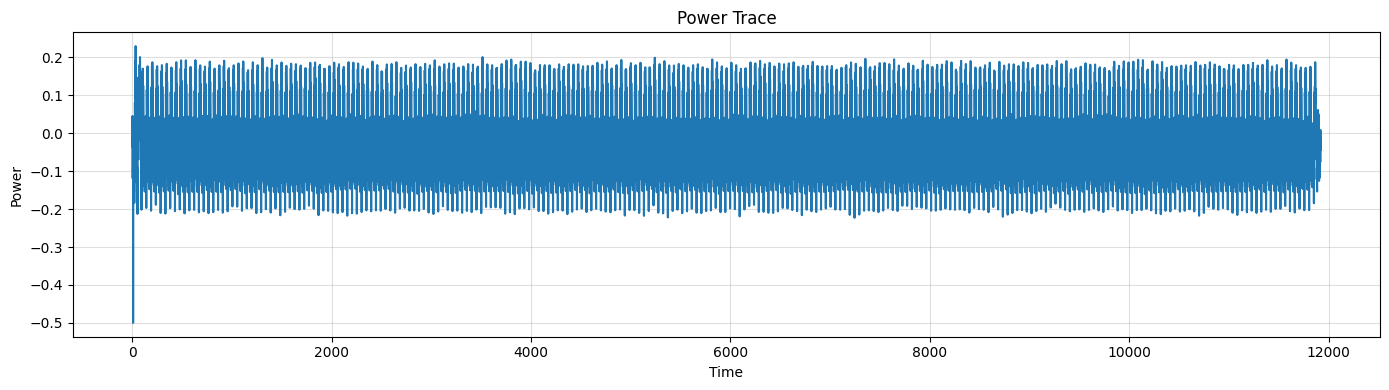

In [14]:
# ── 파형 1개 수집 ───────────────────────────────────────
try:
    data_o, trace = my_get_trace(target, scope)
    # data_o : 타겟 연산 결과 (bytearray)
    # trace  : 전력 파형 (numpy array, 길이 = MAX_TR_LEN)
except (TimeoutError, ValueError) as e:
    print(f'오류 발생: {e}')

print(f'출력값  : {data_o.hex(" ")} ...')
print(f'파형 길이: {len(trace)} 샘플')
print(f'파형 최솟값: {trace.min():.4f},  최댓값: {trace.max():.4f}')

# ── 파형 시각화 ─────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(trace)
plt.title('Power Trace')
plt.xlabel('Time')
plt.ylabel('Power')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

> **파형을 보면서 확인할 사항**
> - 파형이 중간에 잘리지 않는가? → `samples` 값 재조정 필요  
> - 트리거 전 flat한 구간이 보이는가? → `presamples` 적용 효과  
> - 진폭(amplitude)이 너무 크거나 작지 않은가? → `scope.gain` 조정 필요

---

## 💾 3단계: 다량의 파형 수집 및 HDF5 DB 저장

### 3.1 HDF5 포맷 개요

HDF5(Hierarchical Data Format 5)는 대용량 과학 데이터 저장에 특화된 파일 형식입니다.  
파이썬의 `h5py` 라이브러리로 접근하며, 수만~수십만 개의 파형을 효율적으로 관리할 수 있습니다.

```
SCA_DB.h5
├── i_k  [N × data_len]  uint8   ← 입력 키 배열
├── i_p  [N × data_len]  uint8   ← 입력 평문 배열
├── o    [N × data_len]  uint8   ← 연산 출력 배열
└── t    [N × tr_len]   float32  ← 전력 파형 배열
```

N은 수집된 파형 수이며, `maxshape=(None, ...)`으로 설정해 동적으로 확장합니다.

### 3.2 TV(Test Vector) 설정

| `TV_case` | 설명 | 용도 |
|:---------:|:----:|:----|
| `'fixed'`  | 매번 동일한 k, p 사용 | 파형 반복성 확인, 고정 키 t-test |
| `'random'` | 매번 랜덤한 k, p 사용 | 상관분석(CPA) 등 실제 공격 데이터 수집 |

In [15]:
# ══════════════════════════════════════════════════════════
#  스코프 초기화
# ══════════════════════════════════════════════════════════
scope.default_setup()

# ══════════════════════════════════════════════════════════
#  파라미터 설정 및 타겟 리셋
# ══════════════════════════════════════════════════════════
RATIO_DECIMATE = 1
NUM_PRESAMPLES = 0
scope.clock.adc_src = 'clkgen_x4'   # clkgen_x4 clkgen_x1
scope.clock.adc_mul = 4

reset_target(scope)
reset_target(scope)

print('스코프 및 타겟 초기화 완료')

(ChipWhisperer Scope WARNING|File ChipWhispererHuskyClock.py:1628) scope.clock.adc_src is provided for backwards compability, but scope.clock.clkgen_src and scope.clock.adc_mul should be used for Husky.


scope.adc.samples                        changed from 11920                     to 5000                     
스코프 및 타겟 초기화 완료


In [16]:
MAX_DATA_LEN   = 16   # 실제 암호 연산 데이터 크기 (e.g., AES-128이면 16바이트)

# 타겟 초기화 (더미 데이터로 레지스터 설정)
my_fsr_cmd(target, 0x81, 'k', bytearray(MAX_DATA_LEN))   # 16바이트 영벡터
my_fsr_cmd(target, 0x81, 'p', bytearray(MAX_DATA_LEN))
my_fsr_cmd(target, 0x81, 'l', bytearray([MAX_DATA_LEN]))

# 실제 연산 길이를 측정해 scope.adc.samples를 설정하고 그 값을 반환
MAX_TR_LEN = my_setting_num_samples(target, scope, NUM_PRESAMPLES=NUM_PRESAMPLES, RATIO_DECIMATE=RATIO_DECIMATE)

print(f'\n=== 파형 수집 파라미터 ===')
print(f'  데이터 크기    : {MAX_DATA_LEN} 바이트')
print(f'  프리샘플 수    : {NUM_PRESAMPLES}')
print(f'  파형 샘플 수   : {MAX_TR_LEN}')


=== 파형 수집 파라미터 ===
  데이터 크기    : 16 바이트
  프리샘플 수    : 0
  파형 샘플 수   : 928


In [17]:
# ══════════════════════════════════════════════════════════
#  파형 수집 메인 루프
# ══════════════════════════════════════════════════════════

debug_mode   = False   # True: 소량 수집 + 화면 출력 / False: 실제 DB 저장
NUM_OF_TRACES = 10    # 수집할 총 파형 수
FileDir      = '../traces'  # 저장 경로
TV_case      = 'random'      # 'fixed' 또는 'random'

# ── 디버그 모드: 소량 수집 후 파형만 시각화 ─────────────
if debug_mode:
    NUM_OF_TRACES = 5
    array_i_k, array_i_p, array_o, array_t = [], [], [], []

# ── HDF5 파일 생성 (동적 확장 가능한 데이터셋 준비) ──────
with h5py.File(f'{FileDir}/tmp_SCA_DB.h5', 'w') as f:

    # shape=(0, ...) : 초기 행 수 0 (아직 비어있음)
    # maxshape=(None, ...) : 행 방향으로 무제한 확장 허용
    # chunks=True : 청크 단위 저장으로 I/O 성능 향상
    dset_i_k = f.create_dataset('i_k', shape=(0, MAX_DATA_LEN),
                                maxshape=(None, MAX_DATA_LEN), dtype='uint8', chunks=True)
    dset_i_p = f.create_dataset('i_p', shape=(0, MAX_DATA_LEN),
                                maxshape=(None, MAX_DATA_LEN), dtype='uint8', chunks=True)
    dset_o   = f.create_dataset('o',   shape=(0, MAX_DATA_LEN),
                                maxshape=(None, MAX_DATA_LEN), dtype='uint8', chunks=True)
    dset_t   = f.create_dataset('t',   shape=(0, MAX_TR_LEN),
                                maxshape=(None, MAX_TR_LEN),   dtype='float32', chunks=True)

    # ── 수집 루프 ────────────────────────────────────────
    for i in trange(NUM_OF_TRACES, desc='파형 수집 중'):

        # TV 생성
        if TV_case == 'fixed':
            data_i_k = bytearray(b'\xA0' * MAX_DATA_LEN)  # 고정 키
            data_i_p = bytearray(b'\x08' * MAX_DATA_LEN)  # 고정 평문
        elif TV_case == 'random':
            data_i_k = bytearray([random.randint(0, 255) for _ in range(MAX_DATA_LEN)])
            data_i_p = bytearray([random.randint(0, 255) for _ in range(MAX_DATA_LEN)])
        else:
            print('TV_case 오류: fixed 또는 random만 허용됩니다')
            break

        # 타겟 초기화 및 데이터 주입 검증
        # my_fsr_cmd(..., payload_only=True) → 에코 데이터만 bytearray로 반환
        if (
            data_i_k != my_fsr_cmd(target, 0x81, 'k', data_i_k, payload_only=True) or
            data_i_p != my_fsr_cmd(target, 0x81, 'p', data_i_p, payload_only=True) or
            MAX_DATA_LEN != my_fsr_cmd(target, 0x81, 'l',
                                       bytearray([MAX_DATA_LEN]), payload_only=True)[0]
        ):
            print(f'[{i}] 초기화 실패! 해당 파형 건너뜀')
            continue  # 불량 파형 제외하고 다음 반복

        # 파형 수집
        try:
            data_o, trace = my_get_trace(target, scope)
        except (TimeoutError, ValueError) as e:
            print(f'[{i}] 수집 오류: {e}')
            continue

        # ── 디버그 모드: 메모리에만 저장 ─────────────────
        if debug_mode:
            print(f'  [{i}] i_k={data_i_k.hex(" ")}')
            print(f'       i_p={data_i_p.hex(" ")}')
            print(f'       o  ={data_o.hex(" ")}\n')
            array_i_k.append(data_i_k)
            array_i_p.append(data_i_p)
            array_o.append(data_o)
            array_t.append(trace)

        # ── 실제 모드: HDF5에 즉시 저장 (메모리 절약) ────
        else:
            # resize → 행을 1개 늘림
            dset_i_k.resize(dset_i_k.shape[0] + 1, axis=0)
            dset_i_p.resize(dset_i_p.shape[0] + 1, axis=0)
            dset_o.resize(dset_o.shape[0]   + 1, axis=0)
            dset_t.resize(dset_t.shape[0]   + 1, axis=0)

            # 마지막 행에 데이터 기록
            dset_i_k[-1:] = np.array(data_i_k)
            dset_i_p[-1:] = np.array(data_i_p)
            dset_o[-1:]   = np.array(data_o)
            dset_t[-1:]   = np.array(trace)

# ── 수집 완료 후 처리 ────────────────────────────────────
if debug_mode:
    # 수집한 파형 전체를 겹쳐서 시각화
    %matplotlib inline
    plt.figure(figsize=(14, 4))
    plt.plot(np.transpose(np.array(array_t)))
    plt.title(f'{len(array_t)} Power Traces (TV_case={TV_case})')
    plt.xlabel('Samples')
    plt.ylabel('Power')
    plt.grid(True, alpha=0.4)
    plt.show()
else:
    # 타임스탬프로 파일명 생성 → 파일 이름 변경
    d    = time.strftime('%Y%m%d_%H%M%S', time.localtime(time.time()))
    file = Path(f'{FileDir}/tmp_SCA_DB.h5')
    file.rename(f'{FileDir}/{d}_SCA_DB.h5')
    print(f'\n✅ 저장 완료: {FileDir}/{d}_SCA_DB.h5')

print('\nDone!')

파형 수집 중:   0%|          | 0/10 [00:00<?, ?it/s]


✅ 저장 완료: ../traces/20260427_141646_SCA_DB.h5

Done!


In [18]:
# 측정 완료 후 스코프 및 타겟 연결 해제
scope.dis()
target.dis()
print('연결 해제 완료')

연결 해제 완료


---

## 📂 4단계: HDF5 DB 불러오기 및 확인

이미 저장된 `.h5` 파일을 불러와 데이터 형태를 확인하고 파형을 시각화합니다.

### 4.1 파일 불러오기

In [19]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ── 파일 경로 설정 ──────────────────────────────────────
FileDir   = '../traces'
file_path = Path(FileDir) / '20260427_141544_SCA_DB.h5'  # ← 실제 파일명으로 수정

# ── 데이터 로드 ─────────────────────────────────────────
with h5py.File(file_path, 'r') as f:
    i_k = f['i_k'][:]   # shape: (N, data_len)
    i_p = f['i_p'][:]   # shape: (N, data_len)
    o   = f['o'][:]     # shape: (N, data_len)
    t   = f['t'][:]     # shape: (N, tr_len)

print('=== 데이터셋 크기 ===')
print(f'  i_k : {i_k.shape}  (파형 수 × 데이터 길이)')
print(f'  i_p : {i_p.shape}')
print(f'  o   : {o.shape}')
print(f'  t   : {t.shape}   (파형 수 × 샘플 수)')

=== 데이터셋 크기 ===
  i_k : (10, 16)  (파형 수 × 데이터 길이)
  i_p : (10, 16)
  o   : (10, 16)
  t   : (10, 928)   (파형 수 × 샘플 수)


### 4.2 개별 샘플 확인

In [20]:
idx = 0  # 확인할 샘플 인덱스

print(f'=== 샘플 #{idx} ===')
print(f'  i_k : {bytes(i_k[idx]).hex(" ")}')
print(f'  i_p : {bytes(i_p[idx]).hex(" ")}')
print(f'  o   : {bytes(o[idx]).hex(" ")}')

# 결과 검증: o == i_k XOR i_p 인지 확인
expected = bytes(x ^ y for x, y in zip(i_k[idx], i_p[idx]))
match = bytes(o[idx]) == expected
print(f'\n  검증(o == k XOR p): {"✅ 일치" if match else "❌ 불일치"}')

=== 샘플 #0 ===
  i_k : b3 9c cc ad fc 39 c1 c3 68 01 8e 65 ec d1 9c 57
  i_p : e6 65 b8 01 c7 da cf ac 22 fc 7e 94 0a d0 4f cb
  o   : 55 f9 74 ac 3b e3 0e 6f 4a fd f0 f1 e6 01 d3 9c

  검증(o == k XOR p): ✅ 일치


### 4.3 수집된 파형 시각화

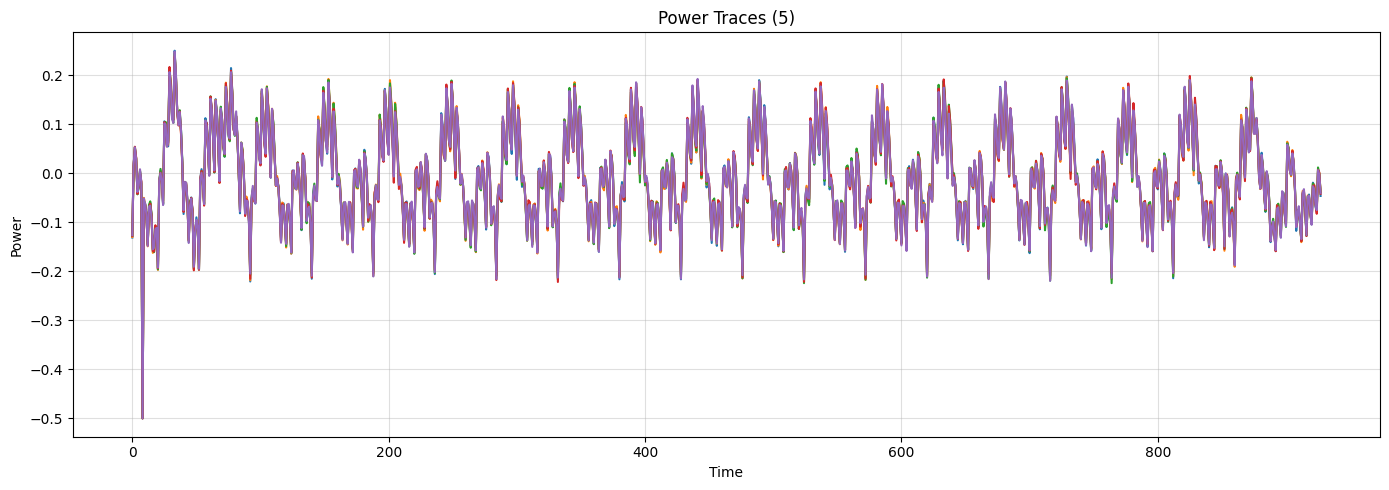


완료!


In [21]:
NUM_PLOT = 5  # 겹쳐 그릴 파형 수

%matplotlib inline
plt.figure(figsize=(14, 5))
plt.plot(t[:NUM_PLOT].T)  # 열 방향으로 transpose해야 각 행이 한 파형
plt.title(f'Power Traces ({NUM_PLOT})')
plt.xlabel('Time')
plt.ylabel('Power')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print('\n완료!')

> 💡 **파형 겹쳐 보기(Overlay)의 의미**
> - 여러 파형이 겹쳤을 때 패턴이 **잘 일치**하면 → 수집이 안정적이며 재현성 높음  
> - 파형들이 **어긋나거나 흔들리면** → 트리거 타이밍 문제, 샘플레이트 조정 필요  
> - Fixed TV에서 파형이 거의 동일하게 보이면 → 이후 CPA/DPA 분석 준비 완료

---

## 📝 실습 요약

| 단계 | 핵심 함수 / 명령 | 결과 |
|:----:|:---|:---|
| 1 | `target.send_cmd()` / `read_cmd()` / `my_fsr_cmd()` | 데이터 송수신 및 골든 모델 검증 |
| 2 | `scope.arm()` → `scope.capture()` → `trig_count` | 연산 구간 측정 및 `samples` 설정 |
| 3 | `my_get_trace()` + `h5py` | 파형 수집 및 HDF5 저장 |
| 4 | `h5py.File(..., 'r')` + `plt.plot()` | DB 불러오기 및 파형 시각화 |

### 다음 단계 예고

충분한 파형 DB가 구축되면 다음 단계로 넘어갑니다:
- **2강**: 상관 전력 분석(CPA, Correlation Power Analysis)  
- **3강**: 딥러닝 기반 부채널 분석(DLSCA)  

---
*ChipWhisperer 입문 강의 — 1강 끝*